In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Simulación de Regresores por Máxima Verosimilitud y Máximo A-Posteriori

### Objetivo
Generar una simulación en Python de los regresores por máxima verosimilitud y máximo a-posteriori discutidos anteriormente, específicamente en la sección 2.1. 

El propósito es ajustar la señal original:

$ t_n = \cos\left(\frac{x_n}{3}\right) + \cos\left(\frac{x_n}{4}\right) + \eta_n, $

donde $x_n \in [0, 24\pi]$, y la señal está contaminada con ruido blanco Gaussiano $\eta_n$ con una relación señal a ruido de $SNRdB= 2[dB]$.

### Supuestos
- Utilizando un mapeo $\phi(\cdot)$ de tipo polinomial de orden $Q$.
- Prior $p(w)$ es una distribución normal $N (w|0, \sigma^2_w)$.

### Datos
- Simula 500 datos para entrenar los modelos.
- Utiliza 200 datos para la predicción.

### Implementación
- Después de generar el mapeo no lineal, se incluye una normalización por `MinMaxScaler()` de `sklearn`.

### Pasos para la Simulación
1. **Generación de Datos**: Simular los 500 datos de entrenamiento y los 200 datos de prueba, contaminados con ruido blanco Gaussiano.
2. **Mapeo Polinomial**: Aplicar un mapeo polinomial de orden $Q$ a los datos.
3. **Normalización**: Normalizar los datos mapeados usando `MinMaxScaler()` de `sklearn`.
4. **Entrenamiento de Modelos**: Entrenar los modelos de regresión por máxima verosimilitud y máximo a-posteriori usando los datos de entrenamiento.
5. **Predicción**: Utilizar los modelos entrenados para predecir los 200 datos de prueba.
6. **Evaluación**: Comparar los resultados de ambos regresores y discutiremos su rendimiento.


Obtenidos los pesos en el punto 2.1, se tiene que :

$W_{ML}=t_{n}^{T} \phi\left (  \phi ^{T}\phi \right )^{-1}$

Se tiene que para MAP :

$W_{MAP}=t_{n}^{T} \phi\left (  \phi ^{T}\phi+\lambda I \right )^{-1}$ siendo
$\lambda= \frac{\sigma ^{2}_{\eta }}{\sigma ^{2}_{\omega}}$

Para convertir la SNR en la potencia del ruido, se debe convertir la SNR de decibelios a una escala lineal (proporcional a la potencia). Esto se hace utilizando la fórmula:
$\text{SNR} = 10 \log_{10} \left( \frac{P_{\text{signal}}}{P_{\text{noise}}} \right)$


**Máxima Verosimilitud **

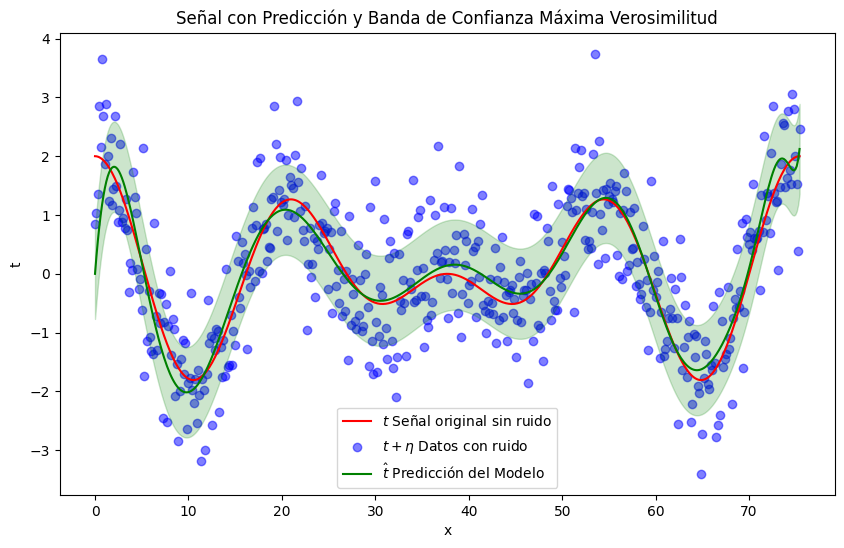

MSE Prueba: 0.6293808351933883
Varianza estimada del modelo: 0.5884564979212801


In [51]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
import matplotlib.pyplot as plt

def generate_data(x_range, n_samples, snr_db):
    """
    Genera datos de entrada x y su correspondiente señal t contaminada con ruido blanco Gaussiano.
    La señal se define como t_n = cos(x_n/3) + cos(x_n/4) + η_n, donde η_n representa el ruido blanco Gaussiano.
    Args:
        x_range (tuple): Rango de valores x (inicio, fin).
        n_samples (int): Número de muestras a generar.
        snr_db (float): Relación señal a ruido en decibelios (dB).
    Returns:
        x (np.ndarray): Valores de x generados.
        signal_with_noise (np.ndarray): Señal generada con ruido.
    """
    x = np.linspace(x_range[0], x_range[1], n_samples).reshape(-1, 1)
    signal = np.cos(x / 3) + np.cos(x / 4)
    noise_variance = np.mean(signal**2) / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_variance), size=signal.shape)
    return x, signal + noise

def polynomial_transform(x, degree):
    """
    Transforma los datos de entrada a un espacio de características polinomiales y los normaliza.
    Args:
        x (np.ndarray): Datos de entrada.
        degree (int): Grado del espacio polinomial.
    Returns:
        np.ndarray: Datos transformados y normalizados.
    """
    poly = PolynomialFeatures(degree=degree)
    x_poly = poly.fit_transform(x)
    scaler = MinMaxScaler()
    x_poly_scaled = scaler.fit_transform(x_poly)
    return x_poly_scaled

def train_model(phi, t):
    """
    Entrena un modelo lineal usando la regresión por mínimos cuadrados.
    Args:
        phi (np.ndarray): Características de entrada transformadas y normalizadas.
        t (np.ndarray): Valores objetivo de la señal.
    Returns:
        w_ml (np.ndarray): Pesos óptimos del modelo.
        sigma2_ml (float): Varianza estimada del ruido.
    """
    w_ml = np.linalg.pinv(phi.T @ phi) @ phi.T @ t
    sigma2_ml = np.mean((t - phi @ w_ml)**2)
    return w_ml, sigma2_ml

def predict(phi, w):
    """
    Realiza predicciones con el modelo entrenado.
    Args:
        phi (np.ndarray): Datos de entrada transformados y normalizados para predicción.
        w (np.ndarray): Pesos del modelo entrenado.
    Returns:
        np.ndarray: Predicciones del modelo.
    """
    return phi @ w

# Parámetros de simulación
x_range = (0, 24 * np.pi)
n_train = 500
n_test = 200
Q = 29  # Grado del polinomio
SNRdB = 2  # SNR en decibelios

# Generación de datos de entrenamiento y prueba
x_train, t_train = generate_data(x_range, n_train, SNRdB)
x_test, t_test = generate_data(x_range, n_test, SNRdB)

# Transformación y normalización de los datos
phi_train = polynomial_transform(x_train, Q)
phi_test = polynomial_transform(x_test, Q)

# Entrenamiento del modelo
w_ml, _ = train_model(phi_train, t_train)

# Predicción en el conjunto de entrenamiento y prueba
t_pred_train = predict(phi_train, w_ml)
t_pred_test = predict(phi_test, w_ml)  # Se realiza la predicción en el conjunto de prueba

# Calculamos la varianza del modelo basada en el conjunto de entrenamiento
var_ml = (np.linalg.norm(t_train - t_pred_train)**2) / len(t_train)

# Cálculo del Error Cuadrático Medio (MSE) para el conjunto de entrenamiento
mse_train = np.mean((t_train - t_pred_train)**2)

# Cálculo del Error Cuadrático Medio (MSE) para el conjunto de prueba
mse_test = np.mean((t_test - t_pred_test)**2)

# Visualización de la señal original, datos con ruido, y predicciones con banda de confianza
plt.figure(figsize=(10, 6))
plt.plot(x_train, signal_original_train, 'r-', label='$t$ Señal original sin ruido')
plt.scatter(x_train, t_train, color='blue', alpha=0.5, label='$t + \eta$ Datos con ruido')
plt.plot(x_train, t_pred_train, 'g-', label='$\hat{t}$ Predicción del Modelo')
plt.fill_between(x_train.ravel(), t_pred_train.ravel() - np.sqrt(var_ml)*np.ones(len(t_pred_train)),
                 t_pred_train.ravel() + np.sqrt(var_ml)*np.ones(len(t_pred_train)), color='green', alpha=0.2)
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.title('Señal con Predicción y Banda de Confianza Máxima Verosimilitud')
plt.show()

#print(f"MSE Entrenamiento: {mse_train}")
print(f"MSE Prueba: {mse_test}")
print(f"Varianza estimada del modelo: {var_ml}")


**Máximo a posteriori.**

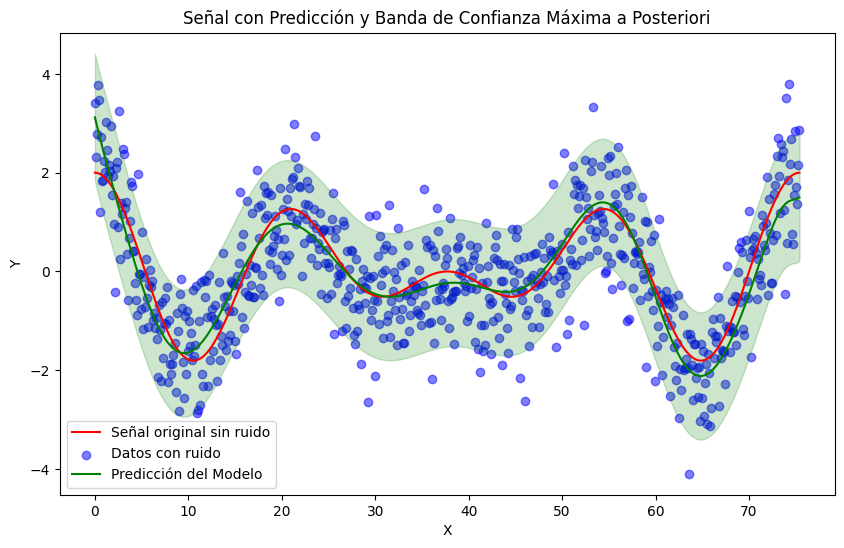

MSE en el conjunto de prueba: 9.842063032818015
Varianza estimada del modelo: 1.6587784167282769


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split

# Fijar semilla para reproducibilidad
np.random.seed(0)

def generate_data(N, snrdB):
    """
    Genera una señal compuesta y su versión contaminada por ruido Gaussiano.

    Args:
        N (int): Total de muestras.
        snrdB (float): Relación señal-ruido en decibelios.

    Returns:
        X (np.ndarray): Vector de tiempo.
        Y_true (np.ndarray): Señal original sin ruido.
        Y (np.ndarray): Señal contaminada con ruido Gaussiano.
    """
    X = np.linspace(0, 24*np.pi, N)
    Y_true = np.cos(X/3) + np.cos(X/4)
    Px = np.mean(Y_true**2)
    var_noise = Px / (10**(snrdB/10))
    Y = Y_true + np.random.normal(0, np.sqrt(var_noise), len(X))
    return X.reshape(-1,1), Y_true, Y.reshape(-1,1)

def scale_features(X, Y):
    """
    Normaliza las características y las etiquetas a un rango [0, 1].

    Args:
        X (np.ndarray): Vector de tiempo como características.
        Y (np.ndarray): Señal como etiquetas.

    Returns:
        X_scaled, Y_scaled: Características y etiquetas normalizadas.
        scaler_X, scaler_Y: Scalers utilizados para la inversión posterior.
    """
    scaler_X, scaler_Y = MinMaxScaler(), MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    Y_scaled = scaler_Y.fit_transform(Y)
    return X_scaled, Y_scaled, scaler_X, scaler_Y

def MAP(X_train, Y_train, alpha, Q):
    """
    Estimación de máxima a posteriori para regresión polinómica con regularización Ridge.

    Args:
        X_train (np.ndarray): Datos de entrenamiento.
        Y_train (np.ndarray): Etiquetas de entrenamiento.
        alpha (float): Parámetro de regularización.
        Q (int): Grado del polinomio.

    Returns:
        w_map (np.ndarray): Pesos estimados del modelo.
    """
    poly = PolynomialFeatures(degree=Q)
    X_poly_train = poly.fit_transform(X_train)
    lambda_I = alpha * np.eye(X_poly_train.shape[1])
    A = X_poly_train.T @ X_poly_train + lambda_I
    b = X_poly_train.T @ Y_train
    w_map = np.linalg.inv(A) @ b
    return w_map

def predict_MAP(X, w_map, Q, scaler_X):
    """
    Predicción utilizando los pesos del modelo MAP.

    Args:
        X (np.ndarray): Datos de entrada.
        w_map (np.ndarray): Pesos del modelo MAP.
        Q (int): Grado del polinomio.
        scaler_X (MinMaxScaler): Scaler para transformar las características.

    Returns:
        Y_pred (np.ndarray): Predicciones del modelo.
    """
    poly = PolynomialFeatures(degree=Q)
    X_poly = poly.fit_transform(scaler_X.transform(X.reshape(-1,1)))
    Y_pred = X_poly @ w_map
    return Y_pred

# Parámetros de simulación
N = 700  # Total de muestras
snrdB = 2  # SNR en dB

# Generación de datos
X, Y_true, Y = generate_data(N, snrdB)

# Normalización de los datos
X_scaled, Y_scaled, scaler_X, scaler_Y = scale_features(X, Y)

# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_scaled, test_size=200/N, random_state=42)

# Estimación MAP
Q = 32  # Grado del polinomio
alpha = 1e-13  # Parámetro de regularización
w_map = MAP(X_train, Y_train, alpha, Q)

# Predicción con el modelo MAP
X_range = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)  # Para visualización
Y_pred = predict_MAP(X_range, w_map, Q, scaler_X)

# Realizar predicciones en el conjunto de prueba
Y_pred_test = predict_MAP(X_test, w_map, Q, scaler_X)

# Revertir la normalización de las predicciones para calcular el MSE en el espacio original
Y_pred_test_original = scaler_Y.inverse_transform(Y_pred_test)
Y_test_original = scaler_Y.inverse_transform(Y_test)

# Cálculo del Error Cuadrático Medio (MSE)
mse = np.mean((Y_test_original - Y_pred_test_original) ** 2)

errors = Y_test_original - Y_pred_test_original  # Errores de predicción

# Cálculo de la varianza de los errores
variance = np.var(errors)

# Visualización con banda de confianza
std_error = np.sqrt(variance)  # Desviación estándar de los errores
plt.figure(figsize=(10, 6))
plt.plot(X, Y_true, 'r', label='Señal original sin ruido')
plt.scatter(X, Y, c='b', alpha=0.5, label='Datos con ruido')
plt.plot(X_range, scaler_Y.inverse_transform(Y_pred), 'g', label='Predicción del Modelo')
plt.fill_between(X_range.ravel(), 
                 (scaler_Y.inverse_transform(Y_pred) - std_error).ravel(), 
                 (scaler_Y.inverse_transform(Y_pred) + std_error).ravel(), 
                 color='green', alpha=0.2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Señal con Predicción y Banda de Confianza Máxima a Posteriori')
plt.show()

print(f"MSE en el conjunto de prueba: {mse}")
print(f"Varianza estimada del modelo: {variance}")


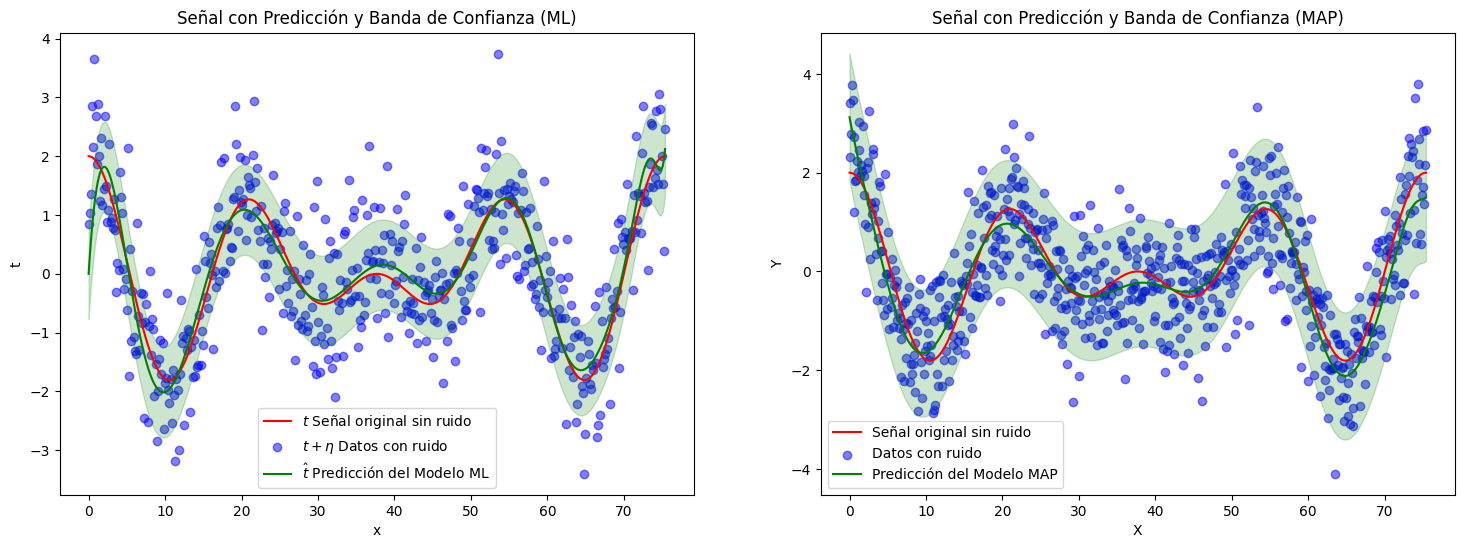

MSE Prueba (ML): 0.6293808351933883
Varianza estimada del modelo (ML): 0.5884564979212801
MSE en el conjunto de prueba (MAP): 9.842063032818015
Varianza estimada del modelo (MAP): 1.6587784167282769


In [56]:
# Visualización de las predicciones de ML y MAP sobre la señal original sin ruido
plt.figure(figsize=(18, 6))

# Gráfica de ML
plt.subplot(1, 2, 1)
plt.plot(x_train, signal_original_train, 'r-', label='$t$ Señal original sin ruido')
plt.scatter(x_train, t_train, color='blue', alpha=0.5, label='$t + \eta$ Datos con ruido')
plt.plot(x_train, t_pred_train, 'g-', label='$\hat{t}$ Predicción del Modelo ML')
plt.fill_between(x_train.ravel(), t_pred_train.ravel() - np.sqrt(var_ml)*np.ones(len(t_pred_train)),
                 t_pred_train.ravel() + np.sqrt(var_ml)*np.ones(len(t_pred_train)), color='green', alpha=0.2)
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.title('Señal con Predicción y Banda de Confianza (ML)')

# Gráfica de MAP
plt.subplot(1, 2, 2)
plt.plot(X, Y_true, 'r', label='Señal original sin ruido')
plt.scatter(X, Y, c='b', alpha=0.5, label='Datos con ruido')
plt.plot(X_range, scaler_Y.inverse_transform(Y_pred), 'g', label='Predicción del Modelo MAP')
plt.fill_between(X_range.ravel(), 
                 (scaler_Y.inverse_transform(Y_pred) - std_error).ravel(), 
                 (scaler_Y.inverse_transform(Y_pred) + std_error).ravel(), 
                 color='green', alpha=0.2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Señal con Predicción y Banda de Confianza (MAP)')

plt.show()

print(f"MSE Prueba (ML): {mse_test}")
print(f"Varianza estimada del modelo (ML): {var_ml}")

print(f"MSE en el conjunto de prueba (MAP): {mse}")
print(f"Varianza estimada del modelo (MAP): {variance}")
